# ML-10 — Content Action Playbook

**Lane:** Content Review Priority Ranking  
**Decision:** Which pseudonymized content pages should an SEO specialist review first, and what kind of review is appropriate?  
**Validated signal:** probability of being associated with an **observed** decline, evaluated on a held-out client-grouped split.  
**Claim limit:** this notebook turns a validated ranking signal into **directional decision-support**. It does not diagnose causes, predict guaranteed future outcomes, or automate content changes.

This notebook builds directly on the Week-5 model and Week-6 validation audit. The queue is generated only for the held-out client group so that the ranked examples remain tied to the honest validation design rather than in-sample scores.


## Setup and validation anchor

I reproduce the Week-5 Random Forest with the same leakage exclusions and the same 75/25 grouped holdout by `client_id`. Week 6 showed that a random row split looked materially stronger than the grouped split, so the grouped result is the headline here.

The target and all direct trend-window fields remain excluded from model features. Client identifiers are used only to create the split and are never displayed or exported.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42

CANDIDATE_PATHS = [
    Path("content_refresh_anonymized.csv"),
    Path("content_refresh_anonymized(1).csv"),
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("../data/raw/content_refresh_anonymized.csv"),
    Path("../../data/raw/content_refresh_anonymized.csv"),
    Path("/mnt/data/content_refresh_anonymized.csv"),
    Path("/mnt/data/content_refresh_anonymized(1).csv"),
]
data_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find content_refresh_anonymized.csv")

df = pd.read_csv(data_path)
y = (df["trend_direction"] == "down").astype(int)
groups = df["client_id"]

forbidden_features = {
    "content_id", "client_id", "trend_direction", "trend_pct",
    "impressions_last_30d", "impressions_prev_30d",
}
feature_columns = [c for c in df.columns if c not in forbidden_features]
X = df[feature_columns].copy()

# Honest client-grouped split, matching Week 5/6.
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
df_train, df_test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

assert set(groups.iloc[train_idx]).isdisjoint(set(groups.iloc[test_idx]))
assert not (set(X.columns) & forbidden_features)

numeric_features = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=8,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])
model.fit(X_train, y_train)
heldout_score = model.predict_proba(X_test)[:, 1]

validation_metrics = {
    "average_precision": float(average_precision_score(y_test, heldout_score)),
    "roc_auc": float(roc_auc_score(y_test, heldout_score)),
    "test_rows": int(len(test_idx)),
    "train_rows": int(len(train_idx)),
    "train_clients": int(groups.iloc[train_idx].nunique()),
    "test_clients": int(groups.iloc[test_idx].nunique()),
    "client_overlap": 0,
}

print(f"Loaded {len(df):,} pseudonymized rows")
print(f"Held-out grouped AP: {validation_metrics['average_precision']:.3f}")
print(f"Held-out grouped ROC AUC: {validation_metrics['roc_auc']:.3f}")
print(f"Client overlap: {validation_metrics['client_overlap']}")


Loaded 30,000 pseudonymized rows
Held-out grouped AP: 0.608
Held-out grouped ROC AUC: 0.623
Client overlap: 0


## 1. Ranked actions + reason codes

The model score answers only **which pages deserve review first**. It does not tell us the cause. To make the queue useful to a human, I add transparent reason codes from non-leaking snapshot features.

Reason codes are intentionally simple:

- `HIGH_MODEL_SCORE` — page is near the top of the validated decline-risk ranking.
- `STALE_UPDATE` — the page has not been updated for at least 180 days.
- `HIGH_IMPRESSION_OPPORTUNITY` — 90-day impressions are in the training-set top quartile.
- `CTR_BELOW_POSITION_NORM` — CTR is below the training median for its search-position bucket.
- `WEAK_ENGAGEMENT` — engagement rate is in the training-set bottom quartile.
- `STRIKING_DISTANCE` — average position is between 4 and 20, where SERP/snippet work may be worth reviewing.

These codes are **review prompts**, not causal explanations. The action mapping below chooses one primary action archetype, but a human must confirm it before any edit.


In [2]:
# Training-only reference values: no held-out outcome information is used to create reason thresholds.
q75_impressions = df_train["impressions_90d"].quantile(0.75)
q25_engagement = df_train["engagement_rate"].quantile(0.25)
score_q80 = np.quantile(heldout_score, 0.80)
score_q95 = np.quantile(heldout_score, 0.95)

POSITION_BINS = [0, 3, 5, 10, 20, np.inf]
POSITION_LABELS = ["1-3", "4-5", "6-10", "11-20", "21+"]

train_pos_bucket = pd.cut(
    df_train["avg_position"], POSITION_BINS,
    labels=POSITION_LABELS, include_lowest=True
)
ctr_median_by_position = (
    df_train.assign(_position_bucket=train_pos_bucket)
    .groupby("_position_bucket", observed=False)["ctr"].median()
)
global_ctr_median = df_train["ctr"].median()

queue = df_test[[
    "content_id", "content_type", "main_intent", "content_age_days",
    "days_since_last_update", "impressions_90d", "ctr", "avg_position",
    "engagement_rate", "ai_traffic_pct"
]].copy()
queue["model_score"] = heldout_score
queue["position_bucket"] = pd.cut(
    queue["avg_position"], POSITION_BINS,
    labels=POSITION_LABELS, include_lowest=True
)
queue["position_ctr_median"] = (
    queue["position_bucket"].map(ctr_median_by_position).astype(float).fillna(global_ctr_median)
)
queue["ctr_below_position_norm"] = queue["ctr"] < queue["position_ctr_median"]

# Business-value proxy is descriptive only; it does not change the validated model score.
queue["value_tier"] = pd.cut(
    queue["impressions_90d"],
    bins=[-np.inf, df_train["impressions_90d"].quantile(.50), q75_impressions, np.inf],
    labels=["lower", "medium", "higher"],
)


def reason_codes(row):
    reasons = []
    if row["model_score"] >= score_q80:
        reasons.append("HIGH_MODEL_SCORE")
    if row["days_since_last_update"] >= 180:
        reasons.append("STALE_UPDATE")
    if row["impressions_90d"] >= q75_impressions:
        reasons.append("HIGH_IMPRESSION_OPPORTUNITY")
    if row["ctr_below_position_norm"]:
        reasons.append("CTR_BELOW_POSITION_NORM")
    if row["engagement_rate"] <= q25_engagement:
        reasons.append("WEAK_ENGAGEMENT")
    if 4 <= row["avg_position"] <= 20:
        reasons.append("STRIKING_DISTANCE")
    return "|".join(reasons) if reasons else "MODEL_SCORE_ONLY"


def action_for(row):
    # Order matters: choose one primary archetype while keeping all reason codes visible.
    if row["model_score"] >= score_q80 and row["days_since_last_update"] >= 180:
        return "REFRESH_REVIEW"
    if row["model_score"] >= score_q80 and row["ctr_below_position_norm"] and 4 <= row["avg_position"] <= 20:
        return "SERP_SNIPPET_REVIEW"
    if row["model_score"] >= score_q80 and row["engagement_rate"] <= q25_engagement:
        return "CONTENT_INTENT_REVIEW"
    if row["model_score"] >= score_q80:
        return "MANUAL_DIAGNOSIS"
    return "MONITOR"


def effort_for(action):
    return {
        "SERP_SNIPPET_REVIEW": "low",
        "MONITOR": "low",
        "CONTENT_INTENT_REVIEW": "medium",
        "REFRESH_REVIEW": "medium-high",
        "MANUAL_DIAGNOSIS": "medium",
    }[action]

queue["reason_codes"] = queue.apply(reason_codes, axis=1)
queue["recommended_action"] = queue.apply(action_for, axis=1)
queue["effort_band"] = queue["recommended_action"].map(effort_for)
queue["priority_band"] = pd.cut(
    queue["model_score"],
    bins=[-np.inf, score_q80, score_q95, np.inf],
    labels=["monitor", "review", "urgent_review"],
    include_lowest=True,
)

# Rank by validated model score first; use impressions only as a deterministic tie-break.
queue = queue.sort_values(
    ["model_score", "impressions_90d"], ascending=[False, False]
).reset_index(drop=True)
queue.insert(0, "rank", np.arange(1, len(queue) + 1))

# Human-facing queue: top 200 is enough to be practical and keeps the paper artifact compact.
ranked_queue = queue.head(200).copy()

summary_cols = [
    "rank", "content_id", "model_score", "recommended_action", "reason_codes",
    "value_tier", "effort_band", "impressions_90d", "ctr", "avg_position",
    "days_since_last_update"
]
display(ranked_queue[summary_cols].head(20).round({"model_score": 3, "ctr": 2, "avg_position": 1}))

print("Action mix in top 200:")
display(
    ranked_queue["recommended_action"].value_counts()
    .rename_axis("action").reset_index(name="count")
)


,rank,content_id,model_score,recommended_action,reason_codes,value_tier,effort_band,impressions_90d,ctr,avg_position,days_since_last_update
0,1,content_e988c1699454,0.951,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT,medium,medium,2197,0.00,21.5,104
1,2,content_9ac61c04930e,0.945,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT|STRIKING_DIST...,medium,medium,1828,0.22,5.6,104
2,3,content_2ba626fea4d6,0.942,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|WEAK_...,lower,low,360,0.00,7.2,104
3,4,content_0d7f4fecb391,0.918,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT,lower,medium,784,0.00,33.0,104
4,5,content_bb1edbf0ba6c,0.915,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|STRIK...,medium,low,1290,0.00,12.4,104
5,6,content_3395aba722a2,0.911,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|STRIK...,medium,low,3320,0.09,11.1,102
6,7,content_b46c62b14582,0.910,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|HIGH_IMPRESSION_OPPORTUNITY|W...,higher,medium,6240,0.13,31.8,103
7,8,content_500bd3907331,0.909,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|WEAK_...,medium,low,4037,0.10,5.5,104
8,9,content_35d63627bf3e,0.909,CONTENT_INTENT_REVIEW,HIGH_MODEL_SCORE|WEAK_ENGAGEMENT,medium,medium,1525,0.00,32.6,103
9,10,content_f6bf66378677,0.907,SERP_SNIPPET_REVIEW,HIGH_MODEL_SCORE|CTR_BELOW_POSITION_NORM|WEAK_...,lower,low,817,0.00,5.7,20


Action mix in top 200:


,action,count
0,SERP_SNIPPET_REVIEW,131
1,CONTENT_INTENT_REVIEW,66
2,MANUAL_DIAGNOSIS,2
3,REFRESH_REVIEW,1


### Archetype → action interpretation

- **REFRESH_REVIEW:** inspect factual freshness, coverage gaps, outdated examples, and whether the page still matches current search intent. Do not rewrite solely because the model score is high.
- **SERP_SNIPPET_REVIEW:** inspect title/meta/snippet alignment and query intent when CTR is weak relative to pages in a similar position range.
- **CONTENT_INTENT_REVIEW:** inspect whether the content satisfies the intended task when engagement is weak. Engagement can be noisy, so this is a prompt for review rather than proof of poor quality.
- **MANUAL_DIAGNOSIS:** the model score is high but the simple reason codes do not point to one obvious archetype. A specialist should investigate manually before deciding on an intervention.
- **MONITOR:** not currently in the high-score review band. Keep under observation rather than spending editing capacity now.

**Cost/value thinking:** the queue stays ranked by the validated model score. `value_tier` (90-day impressions) and `effort_band` help a specialist decide where limited time may have more upside, but they are not presented as validated treatment-effect estimates.


## 2. Intended use and limits

**Intended user:** an SEO/content specialist managing a finite review backlog.

**Intended use:** triage pseudonymized pages into a review queue, then use the reason codes and action archetype to decide what to inspect first. The output is useful when review capacity is limited and a human needs a consistent starting point.

**Measured evidence:** the ranking signal is evaluated on whole held-out clients, not a random row split. In this run, grouped average precision is printed above and is the number I would cite in the paper.

**Limits:**

- The label is retrospective (`trend_direction == "down"`), so the model is not a guaranteed future forecast.
- The model learns associations in the available snapshot features; it does not establish causality.
- A recommended action is a **review hypothesis**, not evidence that the action will improve performance.
- The queue should not be interpreted as a treatment-effect ranking or ROI forecast.
- Distribution shifts in clients, content mix, search behavior, tracking, or feature definitions can make the ranking stale.
- The grouped validation result is materially weaker than a naïve random split, so random-split performance should not be used as the headline claim.


In [3]:
use_limits = pd.DataFrame([
    ["Use", "Prioritize human review of pseudonymized pages"],
    ["Evidence", f"Held-out client-grouped AP = {validation_metrics['average_precision']:.3f}"],
    ["Decision type", "Directional decision-support"],
    ["Not valid for", "Causal diagnosis, guaranteed forecasting, autonomous editing, treatment-effect/ROI claims"],
], columns=["item", "statement"])
display(use_limits)


,item,statement
0,Use,Prioritize human review of pseudonymized pages
1,Evidence,Held-out client-grouped AP = 0.608
2,Decision type,Directional decision-support
3,Not valid for,"Causal diagnosis, guaranteed forecasting, auto..."


## 3. Human review + the no-go list

Every action in the queue requires human review. The model decides **priority**, not the final edit.

### Human review checklist

Before acting, the reviewer should check:

1. **Search intent:** does the page still answer the current task behind the query?
2. **SERP context:** are rankings/CTR changes plausibly explained by SERP layout, brand effects, seasonality, or competitors rather than the page itself?
3. **Content freshness:** are facts, examples, dates, products, links, or screenshots genuinely outdated?
4. **Analytics quality:** are there tracking changes, sparse data, migrations, or instrumentation issues that could distort the signals?
5. **Business context:** is the page strategically important, constrained by legal/brand requirements, or intentionally low-traffic?
6. **Action fit:** does the evidence actually support the proposed archetype, or should the page be monitored instead?

### No-go list

Do **not** automatically:

- rewrite, delete, redirect, deindex, or merge a page;
- change claims, pricing, legal/compliance text, or brand-sensitive copy;
- infer that a high model score caused the observed decline;
- use client identity, private queries, or leaked trend-window fields as reasons for action;
- claim expected lift or ROI without an intervention experiment or other causal evidence;
- treat `MONITOR` as “safe forever” — it only means lower priority under the current model.


In [4]:
review_rules = pd.DataFrame([
    ["Refresh review", "Confirm factual staleness + intent gap before editing", "No autonomous rewrite"],
    ["SERP/snippet review", "Check SERP layout and query intent before metadata changes", "No title/meta change from score alone"],
    ["Content/intent review", "Inspect engagement context and page task", "No quality diagnosis from engagement alone"],
    ["Manual diagnosis", "Investigate multiple possible causes", "No forced action when evidence is ambiguous"],
], columns=["archetype", "human_check", "no_go"])
display(review_rules)


,archetype,human_check,no_go
0,Refresh review,Confirm factual staleness + intent gap before ...,No autonomous rewrite
1,SERP/snippet review,Check SERP layout and query intent before meta...,No title/meta change from score alone
2,Content/intent review,Inspect engagement context and page task,No quality diagnosis from engagement alone
3,Manual diagnosis,Investigate multiple possible causes,No forced action when evidence is ambiguous


## 4. Monitoring / retrain triggers

The playbook should be monitored because both model performance and feature distributions can drift.

I would track four lightweight signals on each future evaluation batch:

1. **Ranking quality:** average precision on newly observed labels. Trigger review if AP falls by more than **0.10 absolute** from the current grouped-validation anchor.
2. **Score distribution:** compare the median predicted score with the current held-out median. Trigger review if it shifts by more than **0.10 absolute**.
3. **Feature drift:** for core numeric features (`impressions_90d`, `ctr`, `avg_position`, `engagement_rate`, `days_since_last_update`), flag if the new median moves outside the current held-out interquartile range.
4. **Operational drift:** trigger review immediately if tracking definitions, target construction, content taxonomy, or search-platform measurement changes.

Retraining should be considered only after confirming the data pipeline is still valid. A metric drop caused by broken tracking should not be “fixed” by retraining.


In [5]:
monitoring_baseline = {
    "validation_average_precision": validation_metrics["average_precision"],
    "validation_roc_auc": validation_metrics["roc_auc"],
    "median_model_score": float(np.median(heldout_score)),
    "score_q25": float(np.quantile(heldout_score, .25)),
    "score_q75": float(np.quantile(heldout_score, .75)),
    "numeric_feature_reference": {},
    "triggers": {
        "ap_absolute_drop": 0.10,
        "median_score_absolute_shift": 0.10,
        "numeric_median_outside_reference_iqr": True,
        "schema_or_tracking_change": "immediate_review",
    },
}

for col in ["impressions_90d", "ctr", "avg_position", "engagement_rate", "days_since_last_update"]:
    s = df_test[col].dropna()
    monitoring_baseline["numeric_feature_reference"][col] = {
        "q25": float(s.quantile(.25)),
        "median": float(s.median()),
        "q75": float(s.quantile(.75)),
    }

monitor_table = pd.DataFrame([
    ["Ranking quality", f"AP < {max(0, validation_metrics['average_precision'] - 0.10):.3f}", "Investigate data/model drift before retraining"],
    ["Score distribution", "Median score shifts > 0.10", "Check client/content mix and calibration"],
    ["Feature distribution", "Core median leaves reference IQR", "Inspect feature definition and population drift"],
    ["Pipeline/schema", "Any target/tracking/taxonomy change", "Pause recommendations; re-audit pipeline"],
], columns=["monitor", "trigger", "response"])
display(monitor_table)


,monitor,trigger,response
0,Ranking quality,AP < 0.508,Investigate data/model drift before retraining
1,Score distribution,Median score shifts > 0.10,Check client/content mix and calibration
2,Feature distribution,Core median leaves reference IQR,Inspect feature definition and population drift
3,Pipeline/schema,Any target/tracking/taxonomy change,Pause recommendations; re-audit pipeline


## 5. Exports for the paper

The notebook regenerates a compact top-200 queue in `work/outputs/`. The CSV contains pseudonymized content IDs and no client identifiers, URLs, queries, target labels, or leaked trend fields.

I also write a small metrics/monitoring JSON for traceability and a reusable action-mix figure. The queue CSV is an operational artifact; the notebook is the source of truth for regenerating it.


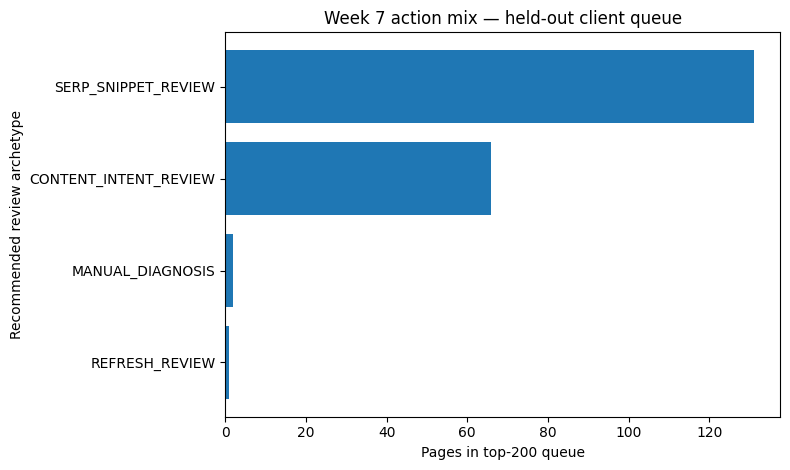

Queue export: /mnt/data/work/outputs/w07_ranked_action_queue.csv
Metrics JSON: /mnt/data/work/outputs/w07_action_playbook_metrics.json
Figure: /mnt/data/work/figures/w07_action_mix.png
Exported rows: 200


In [6]:
# Resolve a repository-like output location while also working in this execution environment.
repo_root = Path.cwd()
if (repo_root / "work").exists():
    base = repo_root
elif Path("/mnt/data/work").exists():
    base = Path("/mnt/data")
else:
    base = repo_root

outputs_dir = base / "work" / "outputs"
figures_dir = base / "work" / "figures"
outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

export_cols = [
    "rank", "content_id", "model_score", "priority_band",
    "recommended_action", "reason_codes", "value_tier", "effort_band",
    "content_type", "main_intent", "content_age_days", "days_since_last_update",
    "impressions_90d", "ctr", "avg_position", "engagement_rate", "ai_traffic_pct",
]
queue_export = ranked_queue[export_cols].copy()

# Privacy/leakage guardrails for the export.
for banned in ["client_id", "trend_direction", "trend_pct", "impressions_last_30d", "impressions_prev_30d"]:
    assert banned not in queue_export.columns
assert not any("url" in c.lower() or "query" in c.lower() for c in queue_export.columns)

queue_path = outputs_dir / "w07_ranked_action_queue.csv"
metrics_path = outputs_dir / "w07_action_playbook_metrics.json"
figure_path = figures_dir / "w07_action_mix.png"

queue_export.to_csv(queue_path, index=False)

artifact_metrics = {
    "validation": validation_metrics,
    "queue": {
        "rows_exported": int(len(queue_export)),
        "urgent_review": int((queue_export["priority_band"].astype(str) == "urgent_review").sum()),
        "review": int((queue_export["priority_band"].astype(str) == "review").sum()),
        "action_counts": queue_export["recommended_action"].value_counts().to_dict(),
    },
    "monitoring_baseline": monitoring_baseline,
    "claim": "directional decision-support for human review; not causal or autonomous",
}
with open(metrics_path, "w") as f:
    json.dump(artifact_metrics, f, indent=2)

# Reusable paper figure; no client information is plotted.
action_counts = queue_export["recommended_action"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(8, 4.8))
plt.barh(action_counts.index, action_counts.values)
plt.xlabel("Pages in top-200 queue")
plt.ylabel("Recommended review archetype")
plt.title("Week 7 action mix — held-out client queue")
plt.tight_layout()
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Queue export:", queue_path)
print("Metrics JSON:", metrics_path)
print("Figure:", figure_path)
print("Exported rows:", len(queue_export))


### Paper-ready claim

> **On a held-out client-grouped split, the model provides a measured ranking signal for pages associated with an observed decline. I use that signal as directional decision-support to prioritize human review, then attach transparent non-leaking reason codes and review archetypes. The playbook does not automate edits, diagnose causes, or claim that a recommended intervention will improve performance.**

This is deliberately narrower than “the model tells us what to fix.” The model tells us **where to look first**; the human review and the evidence on the page determine what, if anything, to change.


## Self-check

Before submission:

- [x] Ranked actions are generated from the validated held-out client queue and include transparent reason codes.
- [x] Intended use, limits, cost/value thinking, and claim boundaries are explicit.
- [x] Human review rules and a no-go list prevent autonomous edits or causal overclaims.
- [x] Monitoring and retraining triggers are concrete and tied to the current validation anchor.
- [x] The queue is exported to `work/outputs/` and contains no client IDs, URLs, private queries, target labels, or leaked trend-window fields.
- [x] A reusable figure and metrics JSON are generated for the paper.
- [x] Claims use careful language: **observed, measured, directional, decision-support**.
- [x] The notebook runs top to bottom with no errors in this environment.
- [ ] Commit this notebook as `work/notebooks/w07_action_playbook.ipynb` (and the reusable figure/metrics artifact allowed by the repo), then submit the repository URL on the assignment card.
